## Model Training

1.1 Import Data and Packages

In [97]:
#Basic Import
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Modelling 

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings(action='ignore')

In [98]:
df= pd.read_csv('data/student.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [99]:
x = df.drop(columns=['math_score'])
x.head()
y= df["math_score"]

In [100]:
x.shape,y.shape

((1000, 7), (1000,))

In [101]:
unique_category=["gender","lunch","parental_level_of_education","race_ethnicity"]
for i in unique_category:
    print("             Category",i)
    print(df[i].unique())
    print()

             Category gender
<StringArray>
['female', 'male']
Length: 2, dtype: str

             Category lunch
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

             Category parental_level_of_education
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

             Category race_ethnicity
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str



In [102]:
#Identify numerical and categorical columns
numerical_features= x.select_dtypes(exclude='object').columns.tolist()
categorical_feature= x.select_dtypes(include='object').columns.tolist()


from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformation=StandardScaler()
oh_transformer=OneHotEncoder()


preprocessor= ColumnTransformer([
    ('OneHotEncoder',oh_transformer,categorical_feature),
    ('StandarScaler',numeric_transformation,numerical_features)
    
])

In [103]:
x=preprocessor.fit_transform(x)

In [104]:
# train test split

from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest= train_test_split(x,y,test_size=0.2,random_state=42)
xtrain.shape,xtest.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [105]:
def evaluate_model(trueValue,predictValue):
    mae= mean_absolute_error(trueValue,predictValue)
    mse= mean_squared_error(trueValue,predictValue)
    rmse= np.sqrt(mse)
    r2score= r2_score(trueValue,predictValue)
    return mae,mse,rmse,r2score
    

In [106]:
#Models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

In [115]:
dict_model_info={}
for i in range(len(models)):
   model=list(models.values())[i]
   model.fit(xtrain,ytrain)
   
   ytrainmodel = model.predict(xtrain)
   ytestmodel=model.predict(xtest)

   model_train_mae ,model_train_mse, model_train_rmse, model_train_r2  = evaluate_model(ytrain, ytrainmodel)
   model_test_mae ,model_test_mse, model_test_rmse, model_test_r2  = evaluate_model(ytest, ytestmodel)

   print(list(models.keys())[i])
   print()
   print('Model performance for Training set')
   print("- Root Mean Squared Error: {:.4f}".format(model_train_mse))
   print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
   print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
   print("- R2 Score: {:.4f}".format(model_train_r2))

   print("-"*40)

   print('Model performance for Test set')
   print("- Root Mean Squared Error: {:.4f}".format(model_test_mse))
   print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
   print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
   print("- R2 Score: {:.4f}".format(model_test_r2))
   dict_model_info[list(models.keys())[i]]=model_test_r2
   print("="*40)
   print()
   print()

Linear Regression

Model performance for Training set
- Root Mean Squared Error: 28.3349
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------------
Model performance for Test set
- Root Mean Squared Error: 29.0952
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso

Model performance for Training set
- Root Mean Squared Error: 43.4784
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------------
Model performance for Test set
- Root Mean Squared Error: 42.5064
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge

Model performance for Training set
- Root Mean Squared Error: 28.3378
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------------
Model performance for Test set
- Root Mean Squared Error: 29.0563
- Root Mean Squar

In [123]:
df_model_info=pd.DataFrame([dict_model_info])
df_model_info.head()

,Linear Regression,Lasso,Ridge,K-Neighbors Regressor,Decision Tree,Random Forest Regressor,XGBRegressor,CatBoosting Regressor,AdaBoost Regressor
0,0.880433,0.82532,0.880593,0.783681,0.714616,0.849438,0.827797,0.851632,0.844647


In [ ]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(xtrain, ytrain)
y_pred = lin_model.predict(xtest)
score = r2_score(ytest, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


 Accuracy of the model is 88.06


## Plot y_pred and y_test

Text(0, 0.5, 'y_pred')

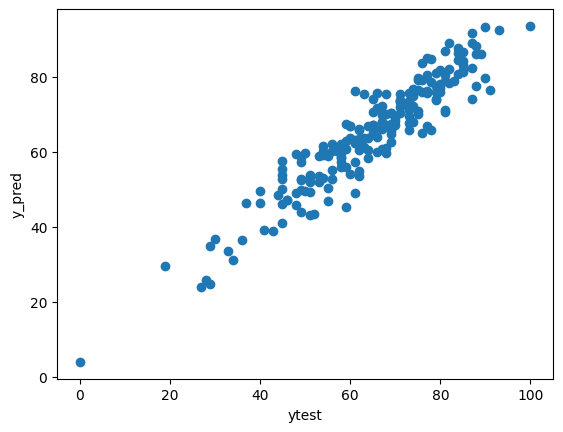

In [131]:
plt.scatter(ytest,y_pred)
plt.xlabel('ytest')
plt.ylabel('y_pred')


## Difference Between actual and predicted

In [135]:
diff=pd.DataFrame({"Actual":ytest,'Predicted':y_pred,'Difference':ytest-y_pred})
diff['Difference'].mean()

np.float64(-0.2417067305760883)